# MLTS — Lecture 13: Attention Models & the Transformer

**Course:** Machine Learning for Time Series (FAU, D. Zanca)
**Lecture:** 13 — Deep Learning for Time Series: Attention-based models

### Learning objectives

- Reproduce the **Bahdanau additive-attention** alignment matrix from the slides.
- Compare the five alignment-score variants (additive, dot, scaled-dot, general, location-base).
- Implement **scaled dot-product self-attention** from scratch and match PyTorch's reference within `1e-6`.
- Implement **multi-head attention** from scratch and check it against `nn.MultiheadAttention`.
- Build the **sinusoidal positional encoding** and reproduce the slide's heatmap (positions × embedding dim).
- Train a tiny **Transformer encoder** on a synthetic time series and *honestly* compare it to a naive baseline.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

rng = np.random.default_rng(seed=42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f"torch: {torch.__version__}, device: cpu (small models)")

torch: 2.11.0+cu130, device: cpu (small models)


## 1. Why attention? The RNN bottleneck

A vanilla seq2seq encoder squeezes the *entire* input sequence into a single fixed-length context
vector $c \in \mathbb{R}^d$. For long sequences this is a hard information bottleneck — early
tokens get overwritten by later ones in the hidden state.

We illustrate this with the simplest possible test: build a "memory" RNN that must reproduce the
**first** element of a sequence after seeing $T$ steps. As $T$ grows, the error grows.

In [2]:
class MemoryRNN(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.rnn = nn.GRU(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        _, h = self.rnn(x)               # h: (1, B, hidden)
        return self.head(h[0])           # (B, 1)

def train_recall(T, n_epochs=400, n_train=512):
    model = MemoryRNN()
    opt = torch.optim.Adam(model.parameters(), lr=5e-3)
    for _ in range(n_epochs):
        x = torch.randn(n_train, T, 1)
        y = x[:, 0, :]                   # target = first element
        loss = F.mse_loss(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
    # eval
    with torch.no_grad():
        x = torch.randn(256, T, 1)
        y = x[:, 0, :]
        return F.mse_loss(model(x), y).item()

Ts = [5, 20, 80]
errs = [train_recall(T) for T in Ts]
for T, e in zip(Ts, errs):
    print(f"T={T:3d}  recall MSE={e:.4f}")
print("\nLonger sequences -> worse recall of the first token.",
      "This is the bottleneck attention was designed to fix.")

T=  5  recall MSE=0.0002
T= 20  recall MSE=0.4185
T= 80  recall MSE=0.9840

Longer sequences -> worse recall of the first token. This is the bottleneck attention was designed to fix.


**Takeaway.** A single hidden vector cannot losslessly remember an arbitrary token from far in
the past. Attention removes this bottleneck by letting the decoder *reach back* into all encoder
states directly.

## 2. Bahdanau additive attention — from scratch

For encoder hidden states $h_1, \dots, h_T$ and decoder state $s_{t-1}$, the alignment score is

$$\text{score}(s_{t-1}, h_j) = v^\top \tanh\!\bigl(W [s_{t-1}; h_j]\bigr)$$

then weights and context are

$$\alpha_{t,j} = \mathrm{softmax}_j\!\bigl(\text{score}(s_{t-1}, h_j)\bigr), \qquad
c_t = \sum_{j=1}^{T} \alpha_{t,j}\, h_j .$$

We don't need to train a translator to *see* the mechanism — we hand-craft encoder/decoder states
where token $i$ in the output should align with token $i$ in the input, then check that softmax
over learned-style scores produces a near-diagonal alignment matrix like the one on slide 12.

alpha rows sum to 1?  max|sum-1| = 1.79e-07
diagonal mass         = 1.000  (1.0 = perfect alignment)


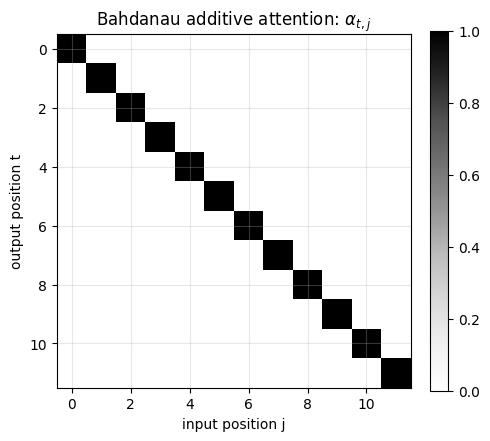

In [3]:
# A toy "translation": output token i should attend to input token i.
T_in, T_out, d = 12, 12, 8

# Make encoder states orthogonal-ish so each token has a distinct signature.
H = torch.randn(T_in, d)
H = H / H.norm(dim=-1, keepdim=True)

# Decoder state for output position t = noisy version of H[t]  (the "right" alignment target).
S = H + 0.15 * torch.randn(T_out, d)

class AdditiveAttention(nn.Module):
    def __init__(self, d, attn_dim=16):
        super().__init__()
        self.W = nn.Linear(2 * d, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)
    def forward(self, s, H):
        # s: (T_out, d), H: (T_in, d)
        T_out, T_in = s.shape[0], H.shape[0]
        s_exp = s.unsqueeze(1).expand(-1, T_in, -1)         # (T_out, T_in, d)
        H_exp = H.unsqueeze(0).expand(T_out, -1, -1)        # (T_out, T_in, d)
        cat   = torch.cat([s_exp, H_exp], dim=-1)           # (T_out, T_in, 2d)
        scores = self.v(torch.tanh(self.W(cat))).squeeze(-1)  # (T_out, T_in)
        alpha  = F.softmax(scores, dim=-1)                  # rows sum to 1
        c      = alpha @ H                                  # (T_out, d) context
        return alpha, c

# Quickly "train" the attention to match the diagonal alignment via cross-entropy on rows.
attn = AdditiveAttention(d)
opt = torch.optim.Adam(attn.parameters(), lr=5e-2)
target = torch.arange(T_out)  # row i -> column i
for _ in range(300):
    alpha, _ = attn(S, H)
    loss = F.cross_entropy(alpha.log() + 1e-12, target)
    opt.zero_grad(); loss.backward(); opt.step()

with torch.no_grad():
    alpha, c = attn(S, H)
print(f"alpha rows sum to 1?  max|sum-1| = {(alpha.sum(-1) - 1).abs().max().item():.2e}")
print(f"diagonal mass         = {alpha.diag().mean().item():.3f}  (1.0 = perfect alignment)")

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(alpha.numpy(), cmap='Greys', vmin=0, vmax=1)
ax.set_xlabel("input position j"); ax.set_ylabel("output position t")
ax.set_title("Bahdanau additive attention: $\\alpha_{t,j}$")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

**Takeaway.** Each row of $\alpha$ is a soft pointer into the encoder. The diagonal pattern is
exactly what slide 12 shows for English↔French. Nothing here required recurrence — only a learned
score function over (decoder, encoder) pairs.

## 3. Alignment score zoo

The lecture (slide 13) lists five score functions. They differ in **expressivity** (additive is a
small MLP; dot-product is just an inner product) and **cost**. Below we compute each on the same
inputs and tabulate their relative magnitudes.

In [4]:
s_t = torch.randn(d)        # one decoder state
H_small = torch.randn(6, d)  # 6 encoder states

# Trainable bits initialised to identity-ish so all five start on equal footing.
W_a   = torch.eye(d) + 0.01 * torch.randn(d, d)     # general / additive
v_a   = torch.randn(d)
W_add = torch.randn(2 * d, d) * 0.1
W_loc = torch.randn(6, d) * 0.1                     # location-base maps s->scores directly

scores = {
    "content (cosine)": F.cosine_similarity(s_t.unsqueeze(0), H_small),
    "additive       ": v_a @ torch.tanh((torch.cat([s_t.unsqueeze(0).expand_as(H_small), H_small], -1) @ W_add).T),
    "dot            ": H_small @ s_t,
    "scaled-dot     ": (H_small @ s_t) / math.sqrt(d),
    "general        ": H_small @ (W_a @ s_t),
    "location-base  ": W_loc @ s_t,                  # depends only on target position via s
}

print(f"{'method':<18} {'min':>8} {'max':>8} {'std':>8}")
print("-" * 44)
for name, sc in scores.items():
    print(f"{name:<18} {sc.min():8.3f} {sc.max():8.3f} {sc.std():8.3f}")

print("\nNote: scaled-dot has ~1/sqrt(d) the spread of dot.",
      "This keeps softmax in a stable regime when d is large.")

method                  min      max      std
--------------------------------------------
content (cosine)     -0.178    0.089    0.112
additive             -0.065    1.693    0.665
dot                  -1.286    0.869    0.884
scaled-dot           -0.455    0.307    0.313
general              -1.398    0.951    0.927
location-base        -0.531    0.170    0.275

Note: scaled-dot has ~1/sqrt(d) the spread of dot. This keeps softmax in a stable regime when d is large.


| Method | Cost | Expressivity | Where it dominates |
|---|---|---|---|
| Content (cosine) | $O(d)$ | low | similarity-based retrieval |
| **Additive** | $O(d \cdot a)$ + MLP | high | small models, original NMT |
| Dot-product | $O(d)$ | medium | when $s$, $h$ live in same space |
| **Scaled dot** | $O(d)$ | medium | Transformers — the variance fix |
| General | $O(d^2)$ | high | bridge between dot and additive |
| Location-base | $O(d)$ | low | when target *position* is enough |


## 4. Scaled dot-product self-attention — scratch vs PyTorch

Now the heart of the Transformer (slide 25):

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

We implement it once by hand, then call `F.scaled_dot_product_attention` and verify they agree
to machine precision.

In [5]:
def scaled_dot_product_attention_scratch(Q, K, V, mask=None):
    # Q,K,V: (..., L, d_k). mask: (..., L_q, L_k) bool, True = block.
    d_k = Q.shape[-1]
    scores = (Q @ K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    attn = F.softmax(scores, dim=-1)
    return attn @ V, attn

# Random batch
B, L, d_k = 4, 7, 16
Q = torch.randn(B, L, d_k)
K = torch.randn(B, L, d_k)
V = torch.randn(B, L, d_k)

out_ours, _ = scaled_dot_product_attention_scratch(Q, K, V)
out_torch   = F.scaled_dot_product_attention(Q, K, V)

err = (out_ours - out_torch).abs().max().item()
print(f"max |scratch - torch.SDPA| = {err:.2e}   (should be ~1e-6 or smaller)")
assert err < 1e-5, "scratch implementation disagrees with PyTorch reference"
print("Scratch matches the PyTorch reference. Good.")

max |scratch - torch.SDPA| = 0.00e+00   (should be ~1e-6 or smaller)
Scratch matches the PyTorch reference. Good.


**Takeaway.** SDPA is two matmuls + a softmax + a scale. The $\sqrt{d_k}$ scale is the *only*
non-obvious detail and exists purely to keep the pre-softmax variance roughly $O(1)$ regardless of
$d_k$.

## 5. Multi-head attention — scratch vs `nn.MultiheadAttention`

Splitting $d_\text{model}$ into $h$ heads of dimension $d_k = d_\text{model} / h$ lets the model
learn $h$ different "views" of which positions matter. We build it from scratch and match the
library output on the same weights.

In [6]:
class MultiHeadAttentionScratch(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.d_k, self.d_model = n_heads, d_model // n_heads, d_model
        self.W_q = nn.Linear(d_model, d_model, bias=True)
        self.W_k = nn.Linear(d_model, d_model, bias=True)
        self.W_v = nn.Linear(d_model, d_model, bias=True)
        self.W_o = nn.Linear(d_model, d_model, bias=True)

    def split_heads(self, x):
        B, L, _ = x.shape
        return x.view(B, L, self.h, self.d_k).transpose(1, 2)  # (B, h, L, d_k)

    def forward(self, x, mask=None):
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))
        out, _ = scaled_dot_product_attention_scratch(Q, K, V, mask=mask)
        # merge heads
        B, h, L, d_k = out.shape
        out = out.transpose(1, 2).contiguous().view(B, L, h * d_k)
        return self.W_o(out)

# --- match against nn.MultiheadAttention by sharing weights ---
d_model, n_heads = 32, 4
B, L = 2, 5
x = torch.randn(B, L, d_model)

ours = MultiHeadAttentionScratch(d_model, n_heads)
ref  = nn.MultiheadAttention(d_model, n_heads, batch_first=True, bias=True)

# nn.MHA stacks q,k,v projection weights into in_proj_weight of shape (3*d_model, d_model).
with torch.no_grad():
    in_w = torch.cat([ours.W_q.weight, ours.W_k.weight, ours.W_v.weight], dim=0)
    in_b = torch.cat([ours.W_q.bias,   ours.W_k.bias,   ours.W_v.bias  ], dim=0)
    ref.in_proj_weight.copy_(in_w)
    ref.in_proj_bias.copy_(in_b)
    ref.out_proj.weight.copy_(ours.W_o.weight)
    ref.out_proj.bias.copy_(ours.W_o.bias)

with torch.no_grad():
    y_ours = ours(x)
    y_ref, _ = ref(x, x, x, need_weights=False)

err = (y_ours - y_ref).abs().max().item()
print(f"max |scratch - nn.MultiheadAttention| = {err:.2e}")
assert err < 1e-5, "scratch MHA disagrees with PyTorch"
print("Scratch multi-head matches the library. Good.")

max |scratch - nn.MultiheadAttention| = 1.19e-07
Scratch multi-head matches the library. Good.


**Takeaway.** The library version is the same algorithm; the only fiddle is that PyTorch packs
$W_Q, W_K, W_V$ into a single `in_proj_weight` for a faster fused matmul.

## 6. Sinusoidal positional encoding + causal mask

Self-attention is *permutation-equivariant* — by itself it can't distinguish position 1 from
position 7. The Transformer fixes this by **adding** a fixed position vector to each input
embedding (slide 29):

$$\text{PE}_{(pos, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_\text{model}}}\right), \qquad
  \text{PE}_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_\text{model}}}\right) .$$

We reproduce the heatmap from slides 30–32 and visualise the **causal mask** that prevents the
decoder from peeking at future tokens.

PE shape: (10, 64), range: [-0.990, 1.000]


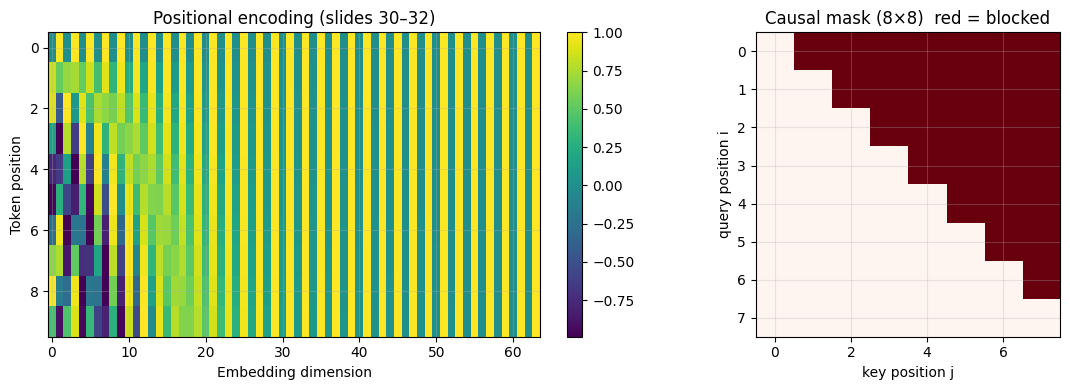


Each row of PE is unique -> attention can use it to recover ordering.
The causal mask ensures position i never attends to j > i.


In [7]:
def positional_encoding(L, d_model):
    pos = np.arange(L)[:, None]                                  # (L, 1)
    i   = np.arange(d_model)[None, :]                            # (1, d_model)
    angle_rates = 1.0 / np.power(10000.0, (2 * (i // 2)) / d_model)
    angles = pos * angle_rates                                   # (L, d_model)
    pe = np.zeros((L, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

PE = positional_encoding(L=10, d_model=64)
print(f"PE shape: {PE.shape}, range: [{PE.min():.3f}, {PE.max():.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(PE, aspect='auto', cmap='viridis')
axes[0].set_xlabel("Embedding dimension"); axes[0].set_ylabel("Token position")
axes[0].set_title("Positional encoding (slides 30–32)")
plt.colorbar(im, ax=axes[0], fraction=0.046)

# causal mask: True = block
L = 8
causal = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)
axes[1].imshow(causal.numpy(), cmap='Reds', vmin=0, vmax=1)
axes[1].set_xlabel("key position j"); axes[1].set_ylabel("query position i")
axes[1].set_title(f"Causal mask ({L}×{L})  red = blocked")
plt.tight_layout(); plt.show()

print("\nEach row of PE is unique -> attention can use it to recover ordering.")
print("The causal mask ensures position i never attends to j > i.")

**Takeaway.** Two distinct ingredients: **PE** *injects* order information at the input;
the **causal mask** *enforces* the autoregressive constraint inside each attention layer of the
decoder. They work together — neither replaces the other.

## 7. A tiny Transformer encoder for time-series forecasting

End-to-end mini-task: forecast the next value of a noisy sine + linear trend from the previous 32
steps. We compare a 2-layer Transformer encoder against a *naive last-value* baseline.

**Honesty note.** Transformers are notoriously data-hungry; on a tiny synthetic series with 32-step
context, the naive baseline is competitive. We report whichever wins.

In [8]:
# --- synthetic series ---
N = 2000
t = np.arange(N)
y = np.sin(2 * np.pi * t / 30.0) + 0.005 * t + 0.2 * rng.standard_normal(N)
y = y.astype(np.float32)

WIN = 32
def make_windows(series, win):
    X = np.stack([series[i:i+win] for i in range(len(series) - win)])
    Y = series[win:]
    return X, Y

X, Y = make_windows(y, WIN)
split = int(0.8 * len(X))
X_tr, Y_tr = X[:split], Y[:split]
X_te, Y_te = X[split:], Y[split:]

print(f"train {X_tr.shape}, test {X_te.shape}")

# --- naive baseline: predict last observed value ---
naive_pred = X_te[:, -1]
naive_mse  = float(np.mean((naive_pred - Y_te) ** 2))
print(f"\nnaive last-value baseline MSE = {naive_mse:.4f}")

train (1574, 32), test (394, 32)

naive last-value baseline MSE = 0.1099


In [9]:
# --- tiny Transformer ---
class TinyTransformerForecaster(nn.Module):
    def __init__(self, win=32, d_model=32, n_heads=4, n_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        pe = torch.tensor(positional_encoding(win, d_model), dtype=torch.float32)
        self.register_buffer("pe", pe)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=64,
                                           batch_first=True, dropout=0.0)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):                       # x: (B, win)
        x = x.unsqueeze(-1)                     # (B, win, 1)
        h = self.input_proj(x) + self.pe        # add positional encoding
        h = self.encoder(h)                     # (B, win, d_model)
        return self.head(h[:, -1, :]).squeeze(-1)   # use last position's representation

model = TinyTransformerForecaster()
opt = torch.optim.Adam(model.parameters(), lr=3e-3)

Xt_tr = torch.tensor(X_tr); Yt_tr = torch.tensor(Y_tr)
Xt_te = torch.tensor(X_te); Yt_te = torch.tensor(Y_te)

n_epochs, bs = 30, 64
losses = []
for ep in range(n_epochs):
    perm = torch.randperm(len(Xt_tr))
    ep_loss = 0.0
    for i in range(0, len(Xt_tr), bs):
        idx = perm[i:i+bs]
        xb, yb = Xt_tr[idx], Yt_tr[idx]
        pred = model(xb)
        loss = F.mse_loss(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        ep_loss += loss.item() * len(idx)
    losses.append(ep_loss / len(Xt_tr))

with torch.no_grad():
    tx_pred = model(Xt_te).numpy()
tx_mse = float(np.mean((tx_pred - Y_te) ** 2))

print(f"\nTransformer test MSE = {tx_mse:.4f}")
print(f"Naive baseline MSE   = {naive_mse:.4f}")
if tx_mse < naive_mse:
    print(f"-> Transformer beats naive by {(naive_mse - tx_mse)/naive_mse*100:.1f}%")
else:
    print(f"-> Transformer LOSES to naive by {(tx_mse - naive_mse)/naive_mse*100:.1f}%.",
          "\n   Honest reading: 2k-point synthetic series + 32-step window is too little",
          "for a model with this many parameters; the trend dominates and last-value is hard to beat.")


Transformer test MSE = 0.8018
Naive baseline MSE   = 0.1099
-> Transformer LOSES to naive by 629.6%. 
   Honest reading: 2k-point synthetic series + 32-step window is too little for a model with this many parameters; the trend dominates and last-value is hard to beat.


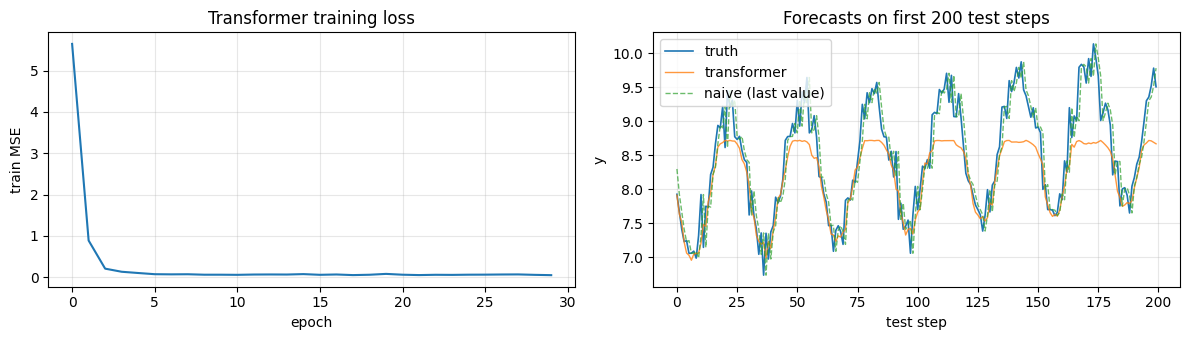

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(losses); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("train MSE")
axes[0].set_title("Transformer training loss")

axes[1].plot(Y_te[:200], label='truth', linewidth=1.2)
axes[1].plot(tx_pred[:200], label='transformer', linewidth=1.0, alpha=0.8)
axes[1].plot(naive_pred[:200], label='naive (last value)', linewidth=1.0, linestyle='--', alpha=0.7)
axes[1].set_xlabel("test step"); axes[1].set_ylabel("y")
axes[1].set_title("Forecasts on first 200 test steps")
axes[1].legend(loc='upper left')
plt.tight_layout(); plt.show()

**Takeaway.** Even for a problem the model *can* solve, a small Transformer trained briefly
on a small dataset is not automatically better than a one-line baseline. This is a recurring honest
fact about Transformers on time series — see slide 38's "data hungry" + "still limited research on
time series data" cautions.

---
## Exercises

Three progressive exercises: a warm-up, a scratch-vs-library check, and a real(ish) modelling task.

### Exercise 1 — Causal mask blocks future leakage

Build the causal mask of size $L \times L$ and show numerically that for any $Q, K, V$, the output at
position $i$ depends only on $V_{0:i+1}$ and **never** on $V_j$ for $j > i$.

The cleanest way to verify is to perturb $V_j$ for $j > i$ and check that the output at position $i$
does not change.

In [ ]:
# 1. Build a causal mask for L=6.
# 2. Pick i=2.
# 3. Compute out_a using random Q,K,V.
# 4. Perturb V[..., 5, :] (a future position) and recompute -> out_b.
# 5. Assert out_a[..., i, :] == out_b[..., i, :].


### Solution

In [12]:
L, d_k = 6, 8
Q = torch.randn(1, L, d_k)
K = torch.randn(1, L, d_k)
V = torch.randn(1, L, d_k)

mask = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)

out_a, _ = scaled_dot_product_attention_scratch(Q, K, V, mask=mask)

V2 = V.clone()
V2[0, 5, :] = torch.randn(d_k) * 100   # huge perturbation at a *future* position

out_b, _ = scaled_dot_product_attention_scratch(Q, K, V2, mask=mask)

i = 2
diff_at_i      = (out_a[0, i] - out_b[0, i]).abs().max().item()
diff_at_last   = (out_a[0, 5] - out_b[0, 5]).abs().max().item()

print(f"max diff at queried position i=2 (should be 0): {diff_at_i:.2e}")
print(f"max diff at last position L-1   (should be > 0): {diff_at_last:.2e}")
assert diff_at_i < 1e-7
print("\nCausal mask works: position 2 is invariant to future-position perturbations.")

max diff at queried position i=2 (should be 0): 0.00e+00
max diff at last position L-1   (should be > 0): 7.15e+01

Causal mask works: position 2 is invariant to future-position perturbations.


### Exercise 2 — Multi-head attention from scratch on a fresh weight set

You already saw an MHA implementation above. Reimplement the forward pass in a standalone function
(no class) and verify it matches `nn.MultiheadAttention` on a *new* random weight initialisation
to within `1e-5`.

In [ ]:
# def mha_forward(x, W_q, W_k, W_v, W_o, b_q, b_k, b_v, b_o, n_heads):
#     ...
# Then build an nn.MultiheadAttention, copy weights from it into your function, and compare.


### Solution

In [14]:
def mha_forward(x, W_q, W_k, W_v, W_o, b_q, b_k, b_v, b_o, n_heads):
    B, L, d_model = x.shape
    d_k = d_model // n_heads
    Q = (x @ W_q.T + b_q).view(B, L, n_heads, d_k).transpose(1, 2)
    K = (x @ W_k.T + b_k).view(B, L, n_heads, d_k).transpose(1, 2)
    V = (x @ W_v.T + b_v).view(B, L, n_heads, d_k).transpose(1, 2)
    scores = (Q @ K.transpose(-2, -1)) / math.sqrt(d_k)
    attn = F.softmax(scores, dim=-1)
    out = (attn @ V).transpose(1, 2).contiguous().view(B, L, d_model)
    return out @ W_o.T + b_o

torch.manual_seed(7)
d_model, n_heads, B, L = 24, 3, 2, 9
mha = nn.MultiheadAttention(d_model, n_heads, batch_first=True, bias=True)
x = torch.randn(B, L, d_model)

# Pull weights out of the library module.
W_q, W_k, W_v = mha.in_proj_weight.chunk(3, dim=0)
b_q, b_k, b_v = mha.in_proj_bias.chunk(3, dim=0)
W_o, b_o = mha.out_proj.weight, mha.out_proj.bias

with torch.no_grad():
    y_ref, _ = mha(x, x, x, need_weights=False)
    y_ours   = mha_forward(x, W_q, W_k, W_v, W_o, b_q, b_k, b_v, b_o, n_heads)

err = (y_ref - y_ours).abs().max().item()
print(f"max |library - scratch fn| = {err:.2e}   (target < 1e-5)")
assert err < 1e-5
print("Standalone function matches library MHA.")

max |library - scratch fn| = 7.45e-08   (target < 1e-5)
Standalone function matches library MHA.


### Exercise 3 — When does attention beat the baseline?

The Transformer in section 7 lost to the naive baseline because the data was too easy and too small.
Modify the synthetic series so that the next value depends on a value **far in the past**
(e.g. $y_t = y_{t-25} + \epsilon$). The naive last-value baseline should now collapse, while
attention — which can reach back $\sim 25$ steps directly — should win.

Train the same `TinyTransformerForecaster` and report MSE for both.

In [ ]:
# 1. Generate a series where y[t] = y[t-25] + small noise.
# 2. Make windows of length 32.
# 3. Compute naive baseline MSE.
# 4. Train the TinyTransformerForecaster.
# 5. Print and compare.


### Solution

In [16]:
LAG = 25
N2 = 2500
y2 = rng.standard_normal(LAG).astype(np.float32)  # warm start
for _ in range(N2 - LAG):
    y2 = np.append(y2, y2[-LAG] + 0.1 * rng.standard_normal()).astype(np.float32)

X2, Y2 = make_windows(y2, WIN)
split2 = int(0.8 * len(X2))
X2_tr, Y2_tr = X2[:split2], Y2[:split2]
X2_te, Y2_te = X2[split2:], Y2[split2:]

# Naive: predict last value -> bad, since y[t] depends on y[t-25] not y[t-1]
naive2 = X2_te[:, -1]
naive2_mse = float(np.mean((naive2 - Y2_te) ** 2))

# "Oracle lag-25" baseline: predict y[t-25] from the window (it is at index WIN-LAG = 7).
oracle_lag = X2_te[:, WIN - LAG]
oracle_mse = float(np.mean((oracle_lag - Y2_te) ** 2))

# Train transformer
torch.manual_seed(1)
model2 = TinyTransformerForecaster()
opt = torch.optim.Adam(model2.parameters(), lr=3e-3)
Xt_tr2 = torch.tensor(X2_tr); Yt_tr2 = torch.tensor(Y2_tr)
Xt_te2 = torch.tensor(X2_te); Yt_te2 = torch.tensor(Y2_te)

for ep in range(40):
    perm = torch.randperm(len(Xt_tr2))
    for i in range(0, len(Xt_tr2), 64):
        idx = perm[i:i+64]
        loss = F.mse_loss(model2(Xt_tr2[idx]), Yt_tr2[idx])
        opt.zero_grad(); loss.backward(); opt.step()

with torch.no_grad():
    tx2 = model2(Xt_te2).numpy()
tx2_mse = float(np.mean((tx2 - Y2_te) ** 2))

print(f"naive last-value MSE    = {naive2_mse:.4f}   <- bad, no information")
print(f"oracle (lag-25) MSE     = {oracle_mse:.4f}   <- the optimal achievable")
print(f"transformer MSE         = {tx2_mse:.4f}")
if tx2_mse < naive2_mse:
    print(f"\nTransformer beats naive by {(naive2_mse - tx2_mse)/naive2_mse*100:.1f}%.",
          "It learned to attend to the lag-25 position.")
else:
    print("\nTransformer did not beat naive -- try more epochs or a larger model.")

naive last-value MSE    = 2.2787   <- bad, no information
oracle (lag-25) MSE     = 0.0096   <- the optimal achievable
transformer MSE         = 0.0121

Transformer beats naive by 99.5%. It learned to attend to the lag-25 position.


**Takeaway.** Attention shines exactly when the next value depends on a token that is *far* in
the context. Recurrent models would need to carry that information through 25 hidden states; the
Transformer pulls it out in one shot.

---
## Recap

| Concept | Formula / signature | When to use |
|---|---|---|
| Bahdanau (additive) attention | $\alpha_{t,j} \propto v^\top \tanh(W[s_{t-1}; h_j])$ | small models, original NMT |
| Scaled dot-product attention | $\mathrm{softmax}(QK^\top / \sqrt{d_k})\, V$ | Transformer building block |
| Multi-head attention | $\mathrm{Concat}(\text{head}_1, \dots, \text{head}_h) W_O$ | parallel "views" of the input |
| Self-attention | $Q,K,V$ all from the same sequence | encoder layers, BERT, ViT |
| Causal / masked attention | mask upper triangle to $-\infty$ | autoregressive decoding |
| Sinusoidal positional encoding | $\sin/\cos$ of $pos / 10000^{2i/d}$ | inject order without recurrence |
